<details>
  <summary><strong>MIT License（クリックで展開）</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>

# セマンティックセグメンテーション（U-Net）による路上障害物検出
今回のハンズオンは，セマンティックセグメンテーションがどのようなものかを体感していただくことが目標です．


## セマンティクセグメンテーションとは


セマンティックセグメンテーション（Semantic Segmentation）は領域分類/領域分割とも呼ばれ，画像のピクセル（画素）1個1個に対しラベルを付与し，画素単位で被写体のタグ付け（分類）を行います．

バウンディングボックス検出と比較した場合，不定形の領域（例：空など）にもラベルを付与可能であることが利点として挙げられます．

自動運転車両・レントゲン等の医用画像など，被写体を識別する場面などで活用されている技術です．

セグメンテーションのイメージ例：
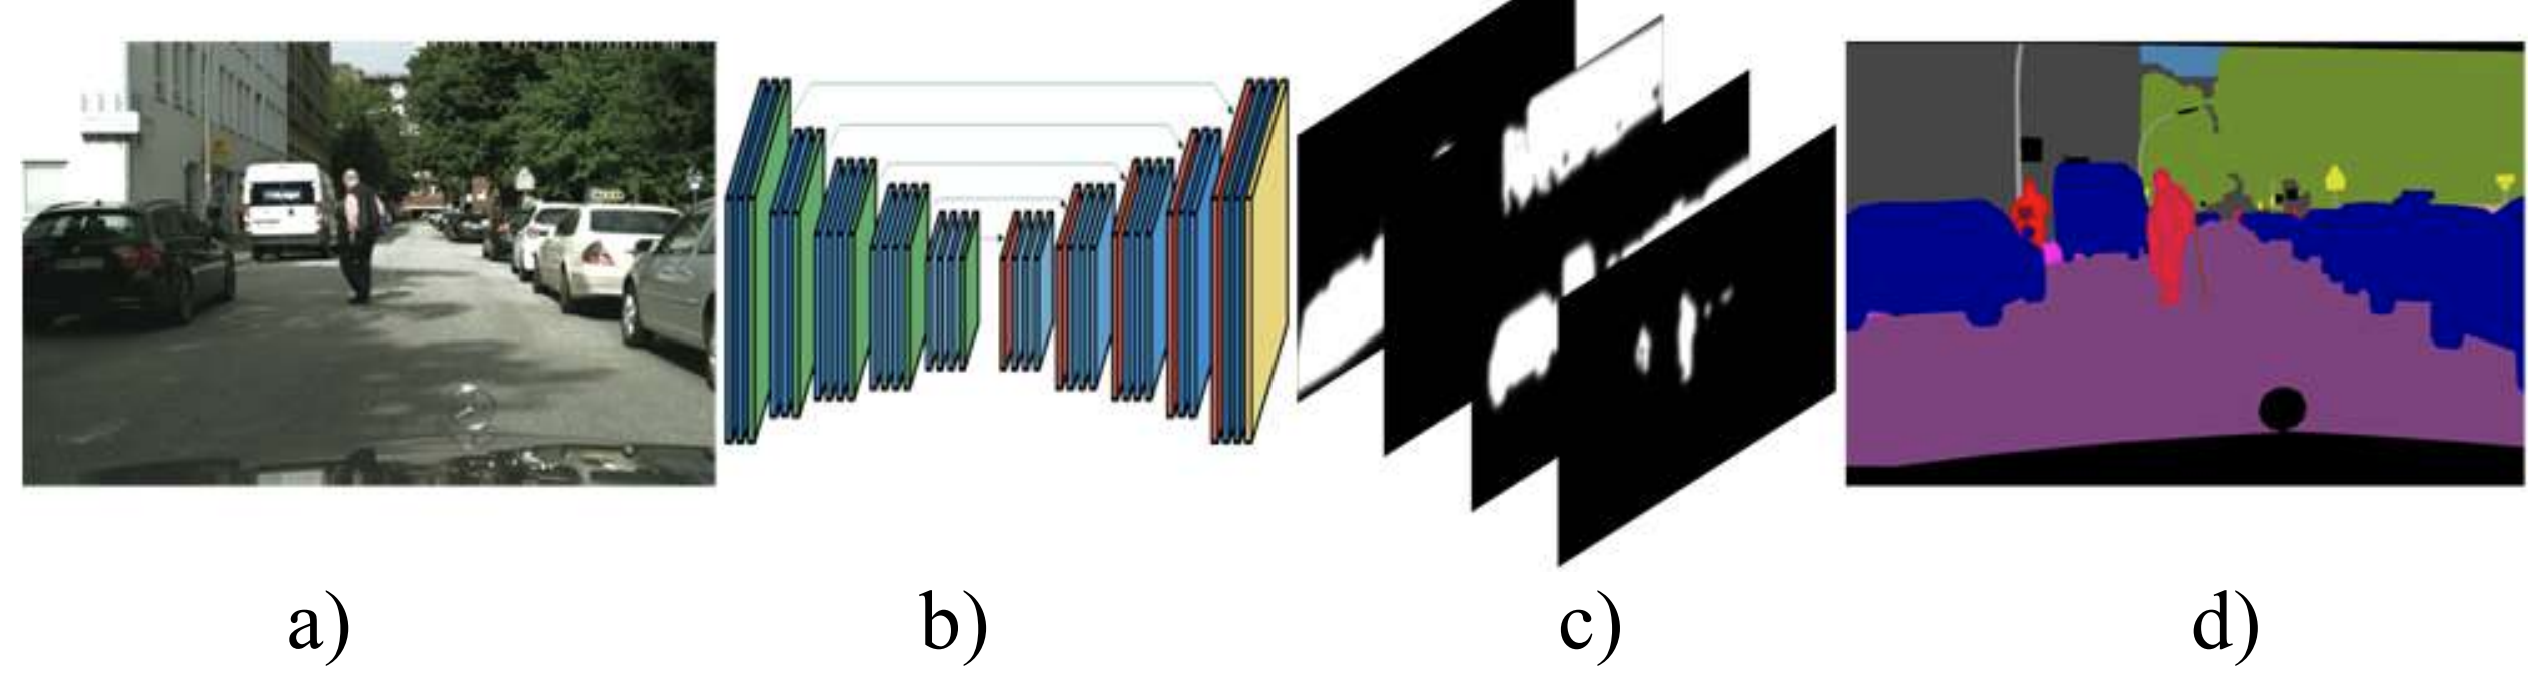
<br>
(a)入力画像 <br>
(b)CNNモデル<br>
(c)CNNモデルからの出力（ラベルのクラス数Cと同じ枚数の確率マップが出力される）<br>
(d)各ピクセルに対しargmax演算し，最も確率が高い推論結果のクラスを描画<br>


---

画像引用元：

On Efficient Real-Time Semantic Segmentation: A Survey  (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/2206.08605



## GPU の利用確認とTensorFlowのバージョン確認

In [1]:
!nvidia-smi

Tue Jun  2 05:11:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
import os


# colab にプリインストールされていないライブラリを導入q
!pip install -q japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

print('TensorFlow version:',tf.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 32.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.20.0


### 外部ライブラリのインストール・ライブラリインポート

In [ ]:
!pip install -qU segmentation-models==1.0.1 #セグメンテーション用のモデルを簡単に実装できるライブラリ

import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import glob # glob:パスを扱う標準ライブラリ

import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

os.environ["SM_FRAMEWORK"] = "tf.keras" # segmentation_modelsで使用するライブラリをTensorFlow内蔵のKerasとする
import segmentation_models as sm #セグメンテーション用のモデルを簡単に実装できるライブラリ

# huggingfaceからのデータセット取得用
from pathlib import Path, PurePosixPath
import zipfile
import shutil
import math
from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.7 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.



今回は下記の擬似乱数シード固定を**行わない**．<br>
（GPU上での決定論的動作に対応していない処理が含まれるため．）
```python
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)
set_seed(42)
```



## データセットの取得

今回のハンズオンで使用するデータセットは [HuggingFace のミラー](https://huggingface.co/datasets/kumuji/lost_and_found) から入手します．

このデータセット「Lost and Found」は，自動運転車両実現ために道路上の障害物を検出することを目的として作成されました．

----
データセット出典：<br>
［arXiv］ [Lost and Found: Detecting Small Road Hazards for Self-Driving Vehicles](https://arxiv.org/abs/1609.04653)

In [4]:
REPO_ID = "kumuji/lost_and_found"
WORK_DIR = Path("./lost_and_found_hf")
EXTRACT_DIR = WORK_DIR / "selected_files"


def download_zip(filename: str) -> str:
    return hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        filename=filename,
        cache_dir=str(WORK_DIR / "hf_cache"),
    )


left_zip_path = download_zip("leftImg8bit.zip")
gt_zip_path = download_zip("gtCoarse.zip")


def _city_and_filename(member: str, anchor: str, split: str):
    parts = PurePosixPath(member).parts
    if anchor not in parts:
        return None

    i = parts.index(anchor)
    if len(parts) < i + 4:
        return None
    if parts[i + 1] != split:
        return None

    city = parts[i + 2]
    filename = parts[-1]
    return city, filename


def collect_pairs(split: str):
    with zipfile.ZipFile(left_zip_path) as left_zf, zipfile.ZipFile(gt_zip_path) as gt_zf:
        gt_index = {}

        for member in gt_zf.namelist():
            got = _city_and_filename(member, "gtCoarse", split)
            if got is None:
                continue

            city, filename = got
            if filename.endswith("_gtCoarse_labelIds.png"):
                stem = filename.removesuffix("_gtCoarse_labelIds.png")
                gt_index[(city, stem)] = member

        pairs = []

        for member in sorted(left_zf.namelist()):
            got = _city_and_filename(member, "leftImg8bit", split)
            if got is None:
                continue

            city, filename = got
            if filename.endswith("_leftImg8bit.png"):
                stem = filename.removesuffix("_leftImg8bit.png")
                label_member = gt_index.get((city, stem))

                if label_member is not None:
                    pairs.append(
                        {
                            "image_member": member,
                            "label_member": label_member,
                            "image_id": stem,
                        }
                    )

    return pairs


def percent_slice(items, start_pct: float, end_pct: float):
    n = len(items)
    start = round(n * start_pct / 100)
    end = round(n * end_pct / 100)
    return items[start:end]


def safe_extract_one(zf: zipfile.ZipFile, member: str, out_dir: Path) -> str:
    parts = [p for p in PurePosixPath(member).parts if p not in ("", ".", "..")]
    target = out_dir.joinpath(*parts)
    target.parent.mkdir(parents=True, exist_ok=True)

    if not target.exists():
        with zf.open(member) as src, open(target, "wb") as dst:
            shutil.copyfileobj(src, dst)

    return str(target)


def extract_selected(pairs):
    extracted = []

    with zipfile.ZipFile(left_zip_path) as left_zf, zipfile.ZipFile(gt_zip_path) as gt_zf:
        for p in pairs:
            image_path = safe_extract_one(left_zf, p["image_member"], EXTRACT_DIR)
            label_path = safe_extract_one(gt_zf, p["label_member"], EXTRACT_DIR)

            extracted.append(
                {
                    "image_path": image_path,
                    "label_path": label_path,
                    "image_id": p["image_id"],
                }
            )

    return extracted


def make_tf_dataset(extracted_rows):
    image_paths = [r["image_path"] for r in extracted_rows]
    label_paths = [r["label_path"] for r in extracted_rows]
    image_ids = [r["image_id"] for r in extracted_rows]

    ds = tf.data.Dataset.from_tensor_slices(
        {
            "image_path": image_paths,
            "label_path": label_paths,
            "image_id": image_ids,
        }
    )

    def load_example(x):
        image = tf.image.decode_png(tf.io.read_file(x["image_path"]), channels=3)
        label = tf.image.decode_png(tf.io.read_file(x["label_path"]), channels=1)

        image = tf.ensure_shape(image, [1024, 2048, 3])
        label = tf.ensure_shape(label, [1024, 2048, 1])

        return {
            "image_id": x["image_id"],
            "image_left": image,
            "segmentation_label": label,
        }

    return ds.map(load_example, num_parallel_calls=tf.data.AUTOTUNE)




all_train_pairs = collect_pairs("train")
all_test_pairs = collect_pairs("test")

train_pairs = percent_slice(all_train_pairs, 0, 5)
valid_pairs = percent_slice(all_train_pairs, 5, 7)
test_pairs = percent_slice(all_test_pairs, 0, 2)

train_rows = extract_selected(train_pairs)
valid_rows = extract_selected(valid_pairs)
test_rows = extract_selected(test_pairs)

dataset = {
    "train": make_tf_dataset(train_rows),
    "valid": make_tf_dataset(valid_rows),
    "test": make_tf_dataset(test_rows),
}

info = {
    "source": "huggingface:kumuji/lost_and_found",
    "features": {
        "image_id": "tf.string",
        "image_left": "tf.uint8, shape=(1024, 2048, 3)",
        "segmentation_label": "tf.uint8, shape=(1024, 2048, 1)",
    },
    "source_num_examples": {
        "train": len(all_train_pairs),
        "test": len(all_test_pairs),
    },
    "num_examples": {
        "train": len(train_rows),
        "valid": len(valid_rows),
        "test": len(test_rows),
    },
}



#######################################################
# 時間短縮のために，データセットの一部のみ使用します．
#######################################################
print(info["num_examples"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


leftImg8bit.zip:   0%|          | 0.00/5.80G [00:00<?, ?B/s]

gtCoarse.zip:   0%|          | 0.00/37.8M [00:00<?, ?B/s]

{'train': 52, 'valid': 21, 'test': 24}


このデータセットは，本来は下記表のようにマスク領域が定義されていますが，<br>
今回使用するデータは一部分だけなので，大幅に簡略化する処理を行います．


|Label | name ID| trainID| description| category|
|----|----|----|----|----|
|’unlabeled’| 0 |255 | - | Miscellaneous |
|’ego vehicle’| 0 |255 | - | Miscellaneous|
|’rectification border’ |0 |255| -|Miscellaneous|
|’out of roi’ |0| 255| -|Miscellaneous|
|’free’ |1| 1| Free space |Counter hypotheses|
|’background’ |0| 0 | Background |Counter hypotheses|
|’01’ |2 |2 |Crate (black) |Standard objects|
|’02’ |3 |2 |Crate (black - 2x stacked)|Standard objects |
|’03’ |4| 2 |Crate (black - upright)| Standard objects|
|’04’ |5| 2| Crate (gray)| Standard objects|
|’05’ |6| 2 |Crate (gray - 2x stacked)|Standard objects|
|’06’ |7| 2| Crate (gray - upright)|Standard objects|
|’07’ |8 |2| Bumper |Random hazards|
|’08’| 9 |2| Cardboard box| Random hazards|
|’09’ |10| 2 |Crate (blue)| Random hazards|
|’10’| 11| 2 |Crate (blue - small)|Random hazards|
|’11’ |12| 2 |Crate (green)|Random hazards|
|’12’| 13| 2 |Crate (green - small)| Random hazards|
|’13’| 14| 2 |Exhaust pipe| Random hazards|
|’14’ |15 |2 |Headlight |Random hazards|
|’15’ |16| 2 |Euro pallet|Random hazards|
|’16’ |17 |2| Pylon|Random hazards|
|’17’ |18| 2 |Pylon (large)|Random hazards|
|’18’ |19 |2 |Pylon (white)|Random hazards|
|’19’ |20| 2 |Rearview mirror|Random hazards|
|’20’ |21| 2 |Tire|Random hazards|
|’29’ |30 |2| Cardboard box|Random hazards|
|’31’ |32 |2| Plastic bag (bloated)|Random hazards|
|’34’ |35 |2| Styrofoam|Random hazards|
|’21’ |22 |2 |Ball |”Emotional” hazards|
|’22’ |23 |2 |Bicycle|”Emotional” hazards|
|’23’ |24 |2 |Dog (black)|”Emotional” hazards|
|’24’ |25 |2 |Dog (white)|”Emotional” hazards|
|’25’ |26 |2 |Kid Dummy|”Emotional” hazards|
|’26’ |27 |2 |Bobby car (gray)|”Emotional” hazards|
|’27’ |28 |2 |Bobby car (red)|”Emotional” hazards|
|’28’ |29 |2 |Bobby car (yellow)|”Emotional” hazards|
|’30’ |31 |0 |Marker pole (lying) |Random non-hazards|
|’32’ |33 |0 |Post (red - lying)|Random non-hazards|
|’33’ |34 |0 |Post stand|Random non-hazards|
|’35’ |36 |0 |Timber (small)|Random non-hazards|
|’36’ |37 |0 |Timber (squared)|Random non-hazards|
|’37’ |38 |0 |Wheel cap|Random non-hazards|
|’38’ |39 |0 |Wood (thin)|Random non-hazards|
|’39’ |40 |2 |Kid (walking) |Humans|
|’40’ |41 |2 |Kid (on a bobby car)|Humans|
|’41’ |42 |2 |Kid (on a small bobby car)|Humans|
|’42’ |43 |2 |Kid (crawling)|Humans|


## 入力データの調整と生成
時間短縮のために，今回のハンズオンでは正解のマスク領域を下記表のように簡略化します．

|マスク領域の数値ラベル | マスク領域の種別名|
|----|----|
|0 | 背景 |
|1 | 走行可能な領域 |
|2 | 路上障害物 |
|3 | その他 |

また，本来の画像サイズは 高1024×幅2048 ですが，Colab上で訓練させるには画像サイズが大きすぎるため，縮小処理を行います．

In [6]:

# 使用する画像サイズ
IMG_SIZE_WIDTH = 256 # 元画像は2048
IMG_SIZE_HEIGHT = 128 # 元画像は1024

TRAIN_LENGTH = dataset['train'].cardinality().numpy()
VALID_LENGTH = dataset['valid'].cardinality().numpy()
TEST_LENGTH = dataset['test'].cardinality().numpy()

BATCH_SIZE = 8
BUFFER_SIZE = 10
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE
VALIDATION_STEPS = VALID_LENGTH // BATCH_SIZE

# 数値ラベルと種別名の対応を定義
mask_label_to_category_name = {
    0 : '背景',
    1 : '走行可能な領域',
    2 : '路上障害物',
    3 : 'その他'
}

@tf.function
def mapping(x):
    ###
    # 簡略化のための正解ラベル調整
    ###

    # Standard objects（物体）,
    # Random hazards（走行上危険な異物）,
    # Random non-hazards（走行上危険ではない異物）
    # Emotional hazards（精神上危険な異物 例：ボール/犬/猫）,
    # humans（人）
    #  -> これらを一括して「路上障害物」の扱いとする
    x = tf.where( ( ( x >= 2 ) & ( x <= 43) ), 2, x)

    # miscellaneous (その他)
    x = tf.where( ( x>=255 )&( x<=255 ), 3, x)

    return x

def normalize(input_image, input_mask):

    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32)

    input_mask = tf.map_fn(fn=mapping, elems=input_mask, fn_output_signature=tf.int32)

    input_mask = tf.reshape(tensor = tf.one_hot(tf.cast(input_mask, tf.int32), depth=len(mask_label_to_category_name), axis=3), \
                            shape = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH, len(mask_label_to_category_name)))

    return input_image, input_mask


def load_image(datapoint):

    input_image = tf.image.resize(images = datapoint['image_left'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                method=tf.image.ResizeMethod.BILINEAR
                                )


    input_mask = tf.image.resize(images = datapoint['segmentation_label'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                antialias=False, # NEAREST_NEIGHBOR の場合は無効
                                # A deterministic GPU implementation of ResizeNearestNeighborGrad is not currently available.
                                # GPUの決定論的動作に対応していない画像補間手法ですが，マスク領域の補間にはこの手法を使います．
                                # 他の画像補間手法は隣接する画素値で平均したりするなど，マスク領域の値が意図しない値へ変わるため不適です．
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
                                #method=tf.image.ResizeMethod.BILINEAR #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.BICUBIC #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.AREA #(maskには不適な補間)
                                )

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask



train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_images = dataset['valid'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

print(f'入力画像サイズ（幅）{IMG_SIZE_WIDTH}')
print(f'入力画像サイズ（高）：{IMG_SIZE_HEIGHT}')

print(f'訓練用データ数：{TRAIN_LENGTH}')
print(f'検証用データ数：{VALID_LENGTH}')
print(f'テスト用データ数：{TEST_LENGTH}')


入力画像サイズ（幅）256
入力画像サイズ（高）：128
訓練用データ数：52
検証用データ数：21
テスト用データ数：24


画像をランダムに左右反転するデータ拡張を，訓練用データセットにのみ適用します．

以上の処理を行った，画像サンプルと対応するデータセットのマスクを可視化します．

(128, 256, 4)
[0 1 2]


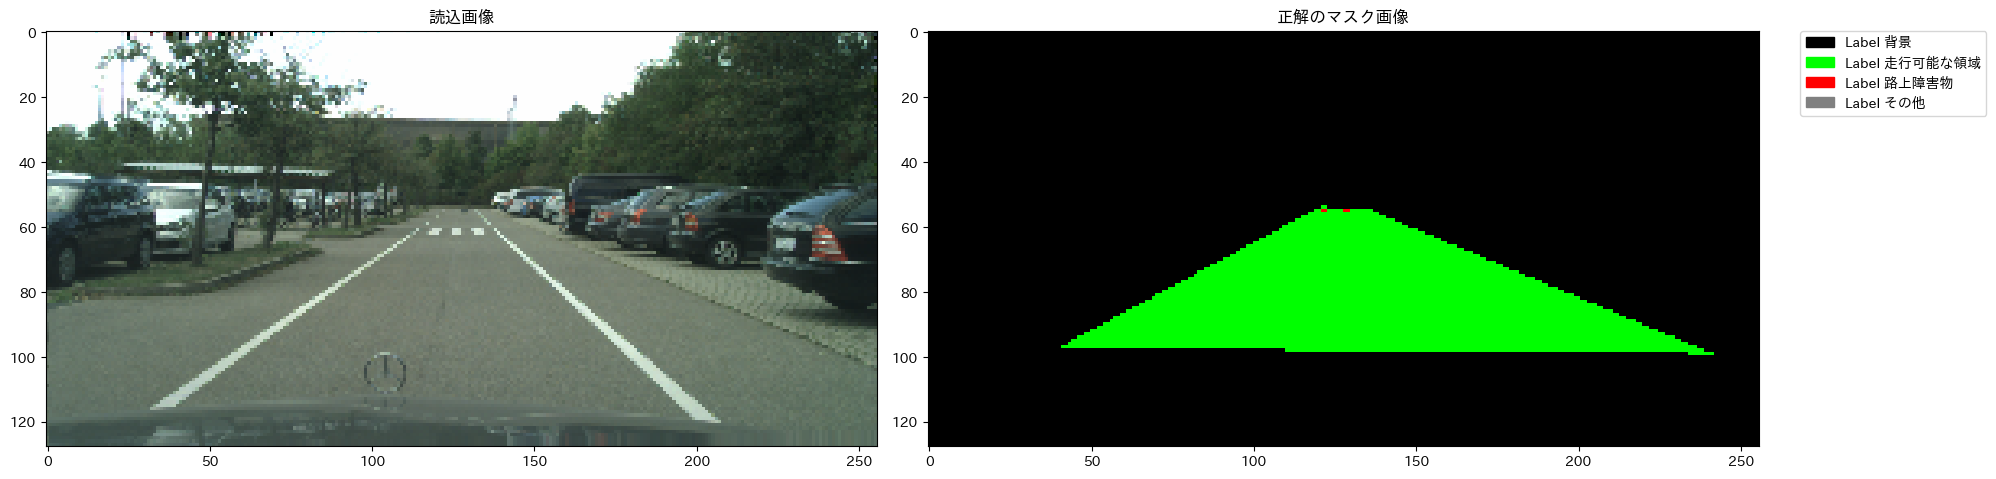

(128, 256, 4)
[0 1 2]


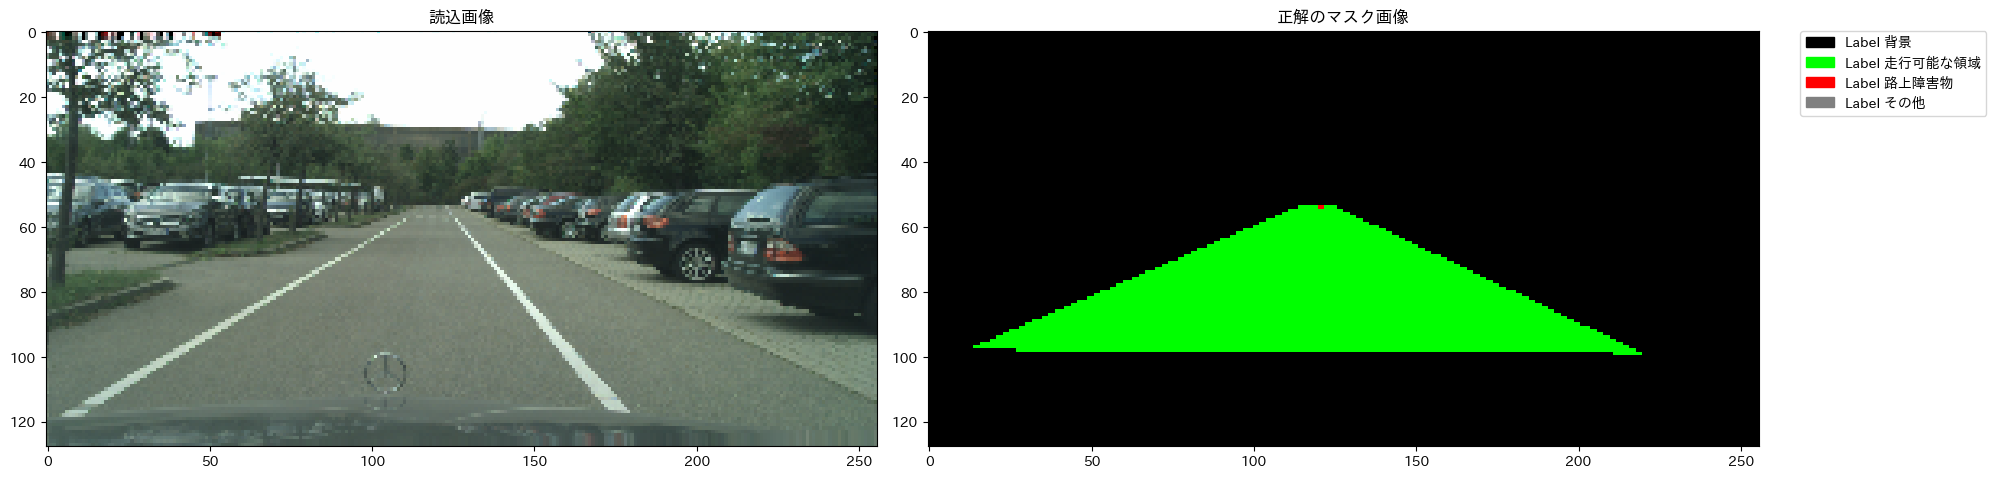

(128, 256, 4)
[0 1 2]


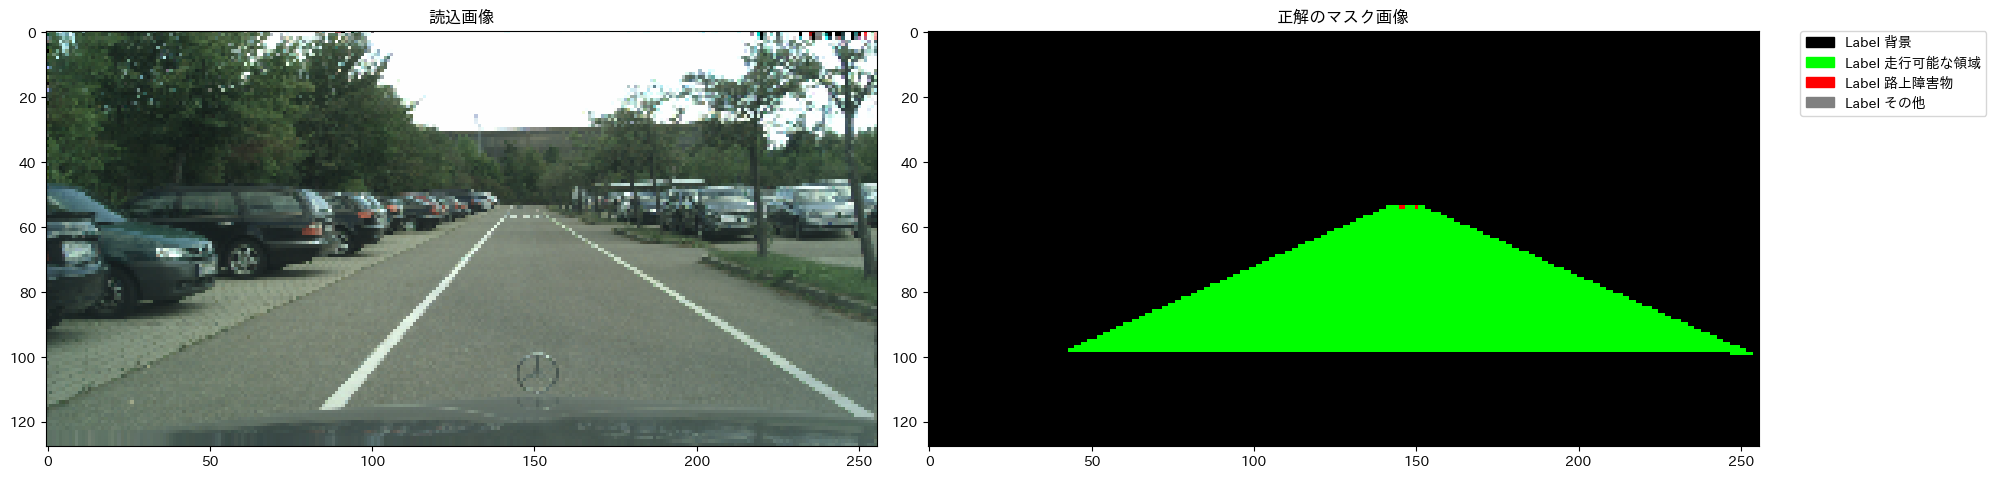

In [7]:
# 画像をランダムに左右反転するデータ拡張を定義する．
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

# 訓練用データセットにのみデータ拡張を適用する．
train_dataset = (
    train_images
    #.cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

# 検証用データセットとテスト用データセットにはデータ拡張を適用しない．
valid_dataset = valid_images.batch(BATCH_SIZE).repeat()
test_dataset = test_images.batch(BATCH_SIZE)


# 以下，サンプル画像の描画用コード

colors = ['black', 'lime', 'red', 'gray']
cmap = ListedColormap(colors, name="custom")
cmap.set_bad('yellow') #無効な値が出力された場合
values = range(len(mask_label_to_category_name))

for images, masks in train_dataset.take(1):
    # 1バッチ中から先頭3枚を描画
    for n in range(3):

        sample_image, sample_mask = images[n], masks[n]

        print(sample_mask.numpy().shape)

        sample_mask = tf.math.argmax(sample_mask, axis=-1)[..., tf.newaxis]

        fig, axes = plt.subplots(1,2, figsize=(20,5))
        axes[0].imshow(sample_image)
        axes[0].set_title('読込画像')

        print(np.unique(sample_mask.numpy()))

        axes[1].imshow(sample_mask, interpolation = 'none', \
                            cmap = cmap, vmin = np.min(values), vmax = np.max(values))
        axes[1].set_title('正解のマスク画像')

        patches = [ mpatches.Patch(color=colors[i], label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
        plt.tight_layout()
        plt.show()

## セグメンテーションモデルの構築

使用モデルは修正 [U-Net](https://arxiv.org/abs/1505.04597) です．

U-Net には，エンコーダ（ダウンサンプラー）とデコーダ（アップサンプラー）が含まれます．
エンコーダ部分の畳み込み演算により，入力画像から特徴抽出を行います．デコーダ部分では，エンコーダによって抽出された特徴マップを逆畳み込み演算により入力画像と同じサイズまで大きくします．

ここでは，事前学習済みモデルをエンコーダとして使用し，訓練時間を短縮します．

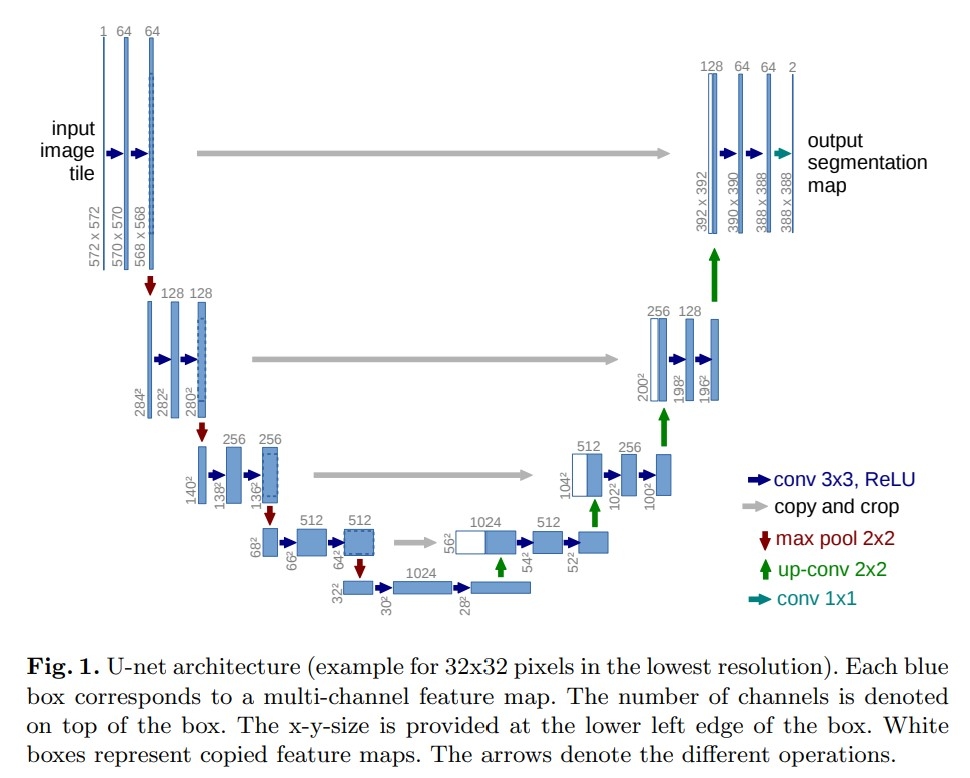

---

画像引用元：

U-Net: Convolutional Networks for Biomedical Image Segmentation (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/1505.04597


モデルを訓練する前に，モデルが何を出力するかを見てみます．

In [8]:
# 描画用関数を定義します．
# このコードセルは実行しても何も出力されませんが，必ず実行してください．

def create_mask(pred_mask, n=0):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[n]


def show_predictions(dataset, num=1):

    colors = ['black', 'lime', 'red', 'gray']
    cmap = ListedColormap(colors, name="custom")
    cmap.set_bad('yellow') #無効な値が出力された場合
    values = range(len(mask_label_to_category_name))

    for image, true_mask in dataset.take(1):
        for n in range(num):

            fig, axes = plt.subplots(1, 3, figsize=(20,5))
            axes[0].imshow(image[n])
            axes[0].set_title('読込画像')

            axes[1].imshow(create_mask(true_mask, n=n), interpolation='none', \
                          cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[1].set_title('正解のマスク画像')

            predict_mask = create_mask( model.predict(image), n=n )
            axes[2].imshow(predict_mask, interpolation='none', \
                                cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[2].set_title('モデルにより推定された領域')

            print(np.unique(predict_mask.numpy().ravel()))

            patches = [ mpatches.Patch(color=colors[i], \
                                        label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]

            plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
            plt.tight_layout()
            plt.show()

モデルを構築して，未訓練状態の出力を見てみます．

/usr/local/lib/python3.12/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
[0 1 2 3]


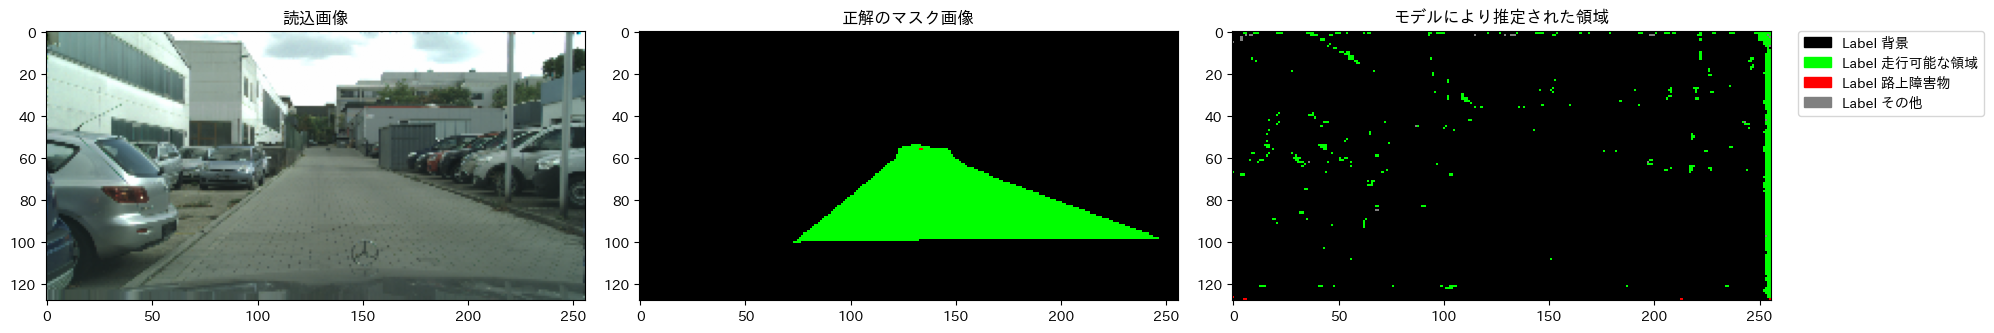

In [9]:
tf.keras.backend.set_image_data_format('channels_last')

model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    'Adam',
    loss=sm.losses.dice_loss,
    metrics=[sm.metrics.iou_score],
)

# 上のコードセルで定義した描画用の関数で，未訓練状態のモデルが何を出力するのか確認する．
show_predictions(test_dataset)

未訓練状態のモデルでは，うまく推論できていないことがよく分かると思います．

ここからモデル訓練を行い，どのように変わっていくのか見てみましょう．

構築されたモデルの構成を簡単に出力します．

In [10]:
# こちらはPNGファイルに出力
tf.keras.utils.plot_model(model, to_file='unet_model.png', show_shapes=True)

# こちらは下に出力
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ Conv1_pad[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis

 Total params: 8,047,876 (30.70 MB)

 Trainable params: 8,011,780 (30.56 MB)

 Non-trainable params: 36,096 (141.00 KB)

## モデルの訓練

今回は，訓練中にモデルがどのように改善されるかを監視するための```DisplayCallback```を作成します．

/usr/local/lib/python3.12/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[0 1 2 3]


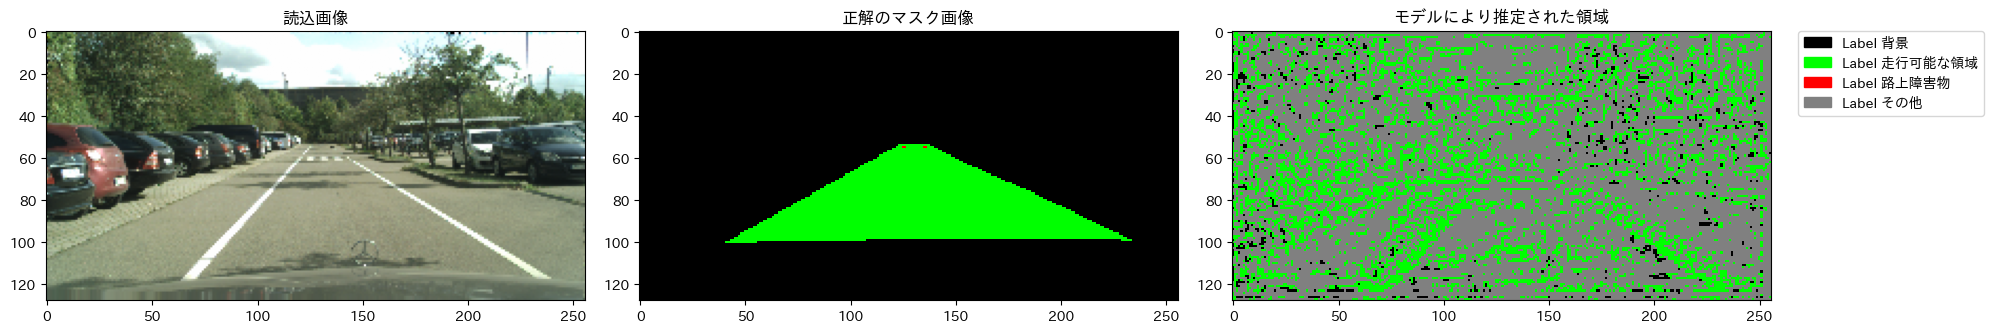


Sample Prediction after epoch 1

6/6 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - iou_score: 0.0808 - loss: 3.5928 - val_iou_score: 0.0585 - val_loss: 3.6776
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 635ms/step - iou_score: 0.1009 - loss: 3.4845 - val_iou_score: 0.0625 - val_loss: 3.6013
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 770ms/step - iou_score: 0.1181 - loss: 3.4028 - val_iou_score: 0.0567 - val_loss: 3.6115
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.1335 - loss: 3.3339 - val_iou_score: 0.0528 - val_loss: 3.6304
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.1476 - loss: 3.2672 - val_iou_score: 0.0521 - val_loss: 3.6351
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - iou_score: 0.1616 - loss: 3.2063 - val_iou_score: 0.0528 - val_loss: 3.6330
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 697ms/step - iou_score: 0.1763 - loss: 3.1472 - val_iou_score: 0.0558 - val_loss: 3.6192
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 922ms/step - iou_score: 0.1902 - loss: 3.0

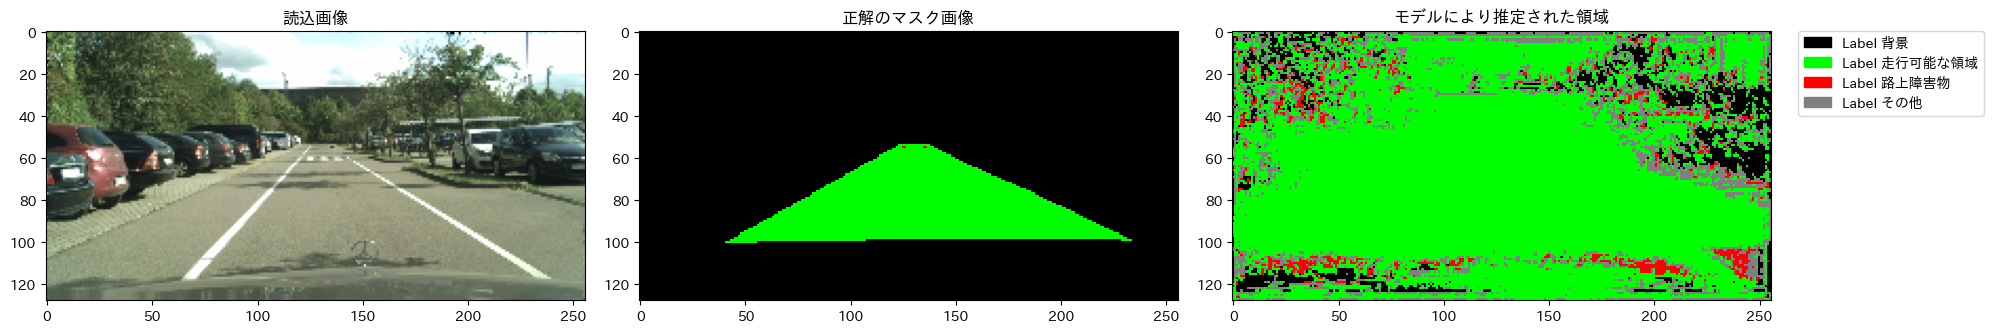


Sample Prediction after epoch 11

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - iou_score: 0.2179 - loss: 2.9761 - val_iou_score: 0.0906 - val_loss: 3.4606
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - iou_score: 0.2251 - loss: 2.9419 - val_iou_score: 0.1034 - val_loss: 3.4056
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - iou_score: 0.2320 - loss: 2.9183 - val_iou_score: 0.1199 - val_loss: 3.3364
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 520ms/step - iou_score: 0.2422 - loss: 2.8876 - val_iou_score: 0.1366 - val_loss: 3.2681
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.2500 - loss: 2.8608 - val_iou_score: 0.1597 - val_loss: 3.1759
Epoch 16/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 904ms/step - iou_score: 0.2552 - loss: 2.8379 - val_iou_score: 0.1776 - val_loss: 3.1065
Epoch 17/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 943ms/step - iou_score: 0.2638 - loss: 2.8069 - val_iou_score: 0.1903 - val_loss: 3.0583
Epoch 18/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - iou_score: 0.2666 - lo

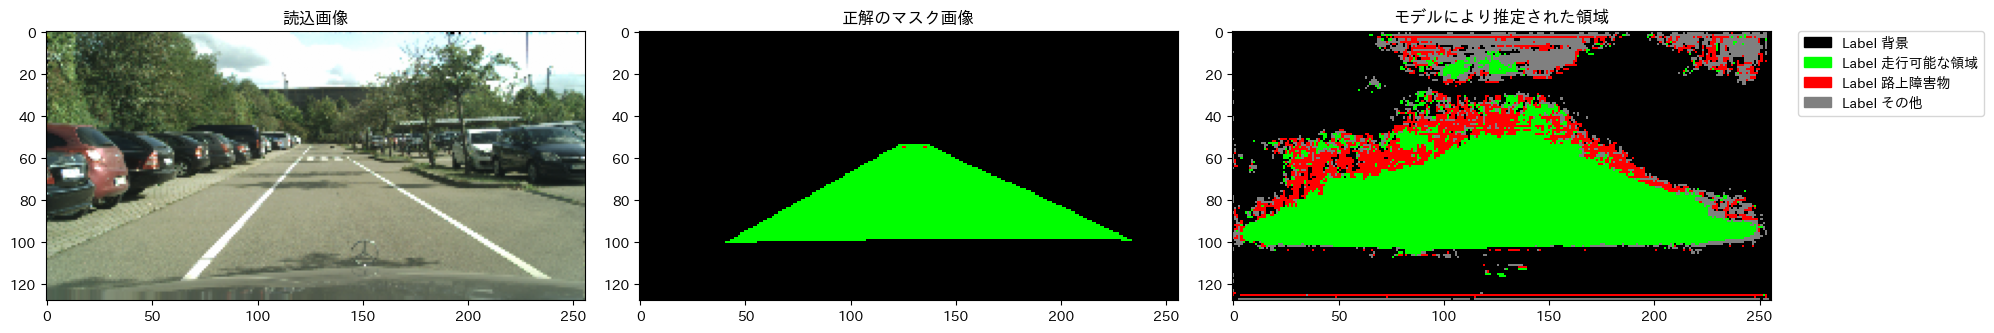


Sample Prediction after epoch 21

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.2868 - loss: 2.7248 - val_iou_score: 0.2222 - val_loss: 2.9404
Epoch 22/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 516ms/step - iou_score: 0.2948 - loss: 2.6984 - val_iou_score: 0.2372 - val_loss: 2.8865
Epoch 23/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 533ms/step - iou_score: 0.3040 - loss: 2.6648 - val_iou_score: 0.2462 - val_loss: 2.8543
Epoch 24/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 736ms/step - iou_score: 0.3045 - loss: 2.6651 - val_iou_score: 0.2488 - val_loss: 2.8449
Epoch 25/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.3125 - loss: 2.6357 - val_iou_score: 0.2613 - val_loss: 2.8017
Epoch 26/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 837ms/step - iou_score: 0.3154 - loss: 2.6309 - val_iou_score: 0.2562 - val_loss: 2.8200
Epoch 27/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 821ms/step - iou_score: 0.3221 - loss: 2.5975 - val_iou_score: 0.2630 - val_loss: 2.7966
Epoch 28/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.3279 - los

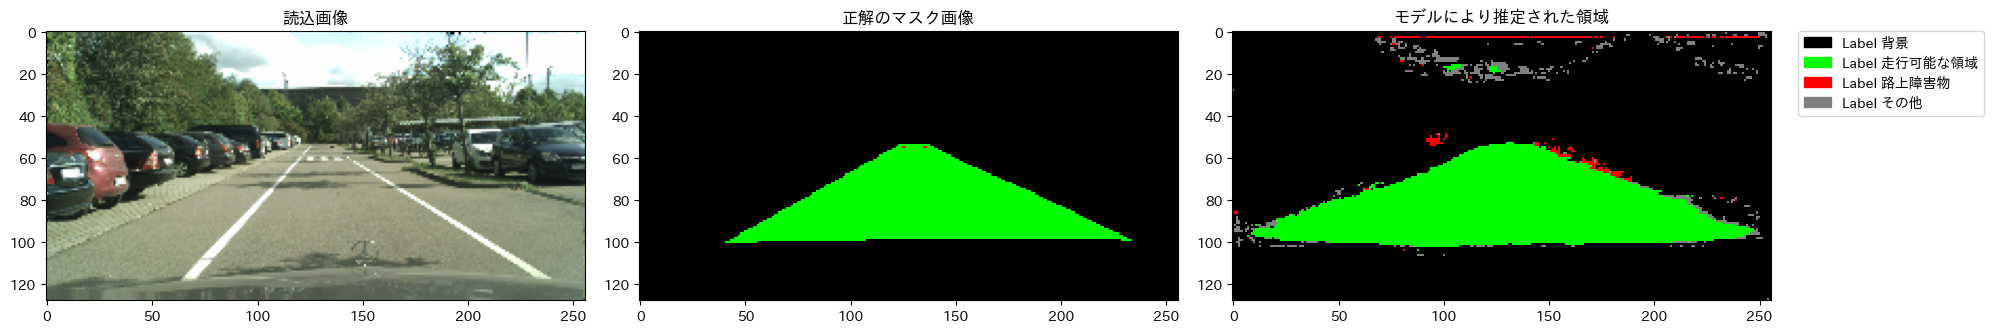


Sample Prediction after epoch 31

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.3427 - loss: 2.5350 - val_iou_score: 0.2673 - val_loss: 2.7796
Epoch 32/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - iou_score: 0.3485 - loss: 2.5038 - val_iou_score: 0.2687 - val_loss: 2.7754
Epoch 33/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 733ms/step - iou_score: 0.3518 - loss: 2.4920 - val_iou_score: 0.2640 - val_loss: 2.7897
Epoch 34/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 935ms/step - iou_score: 0.3566 - loss: 2.4935 - val_iou_score: 0.2651 - val_loss: 2.7873
Epoch 35/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 736ms/step - iou_score: 0.3645 - loss: 2.4560 - val_iou_score: 0.2863 - val_loss: 2.7129
Epoch 36/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 956ms/step - iou_score: 0.3687 - loss: 2.4386 - val_iou_score: 0.2587 - val_loss: 2.8100
Epoch 37/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1000ms/step - iou_score: 0.3718 - loss: 2.4323 - val_iou_score: 0.2814 - val_loss: 2.7308
Epoch 38/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 829ms/step - iou_score: 0.379

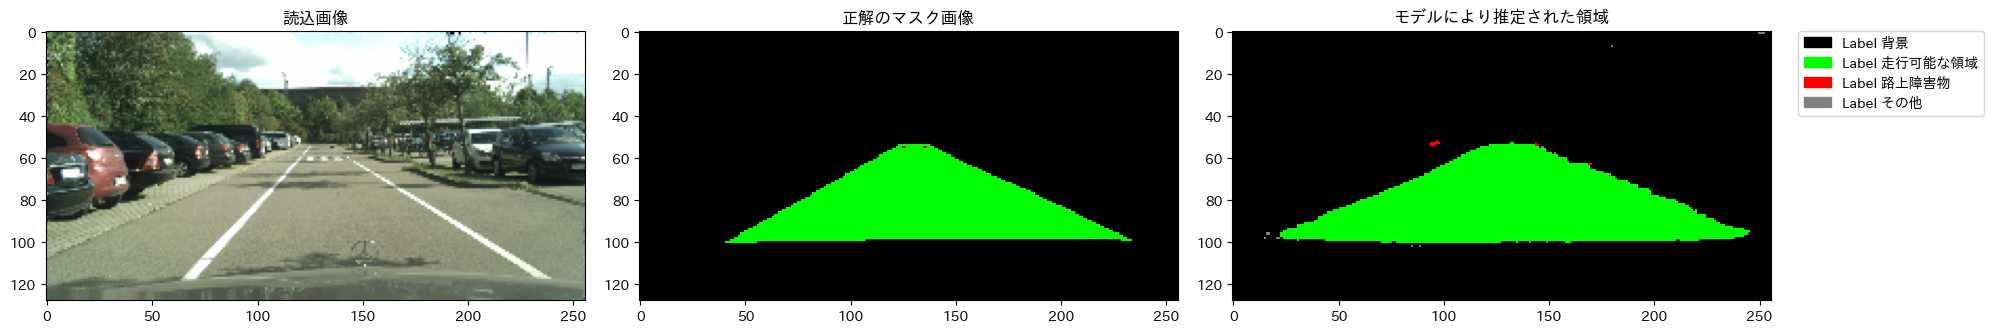


Sample Prediction after epoch 41

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.3904 - loss: 2.3553 - val_iou_score: 0.2939 - val_loss: 2.6865
Epoch 42/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - iou_score: 0.3977 - loss: 2.3297 - val_iou_score: 0.2917 - val_loss: 2.6967
Epoch 43/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - iou_score: 0.3989 - loss: 2.3373 - val_iou_score: 0.3028 - val_loss: 2.6592
Epoch 44/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.4078 - loss: 2.3048 - val_iou_score: 0.3020 - val_loss: 2.6587
Epoch 45/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 985ms/step - iou_score: 0.4107 - loss: 2.2777 - val_iou_score: 0.3045 - val_loss: 2.6522
Epoch 46/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 492ms/step - iou_score: 0.4097 - loss: 2.2773 - val_iou_score: 0.3064 - val_loss: 2.6441
Epoch 47/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 740ms/step - iou_score: 0.4169 - loss: 2.2844 - val_iou_score: 0.3088 - val_loss: 2.6333
Epoch 48/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.4209 - los

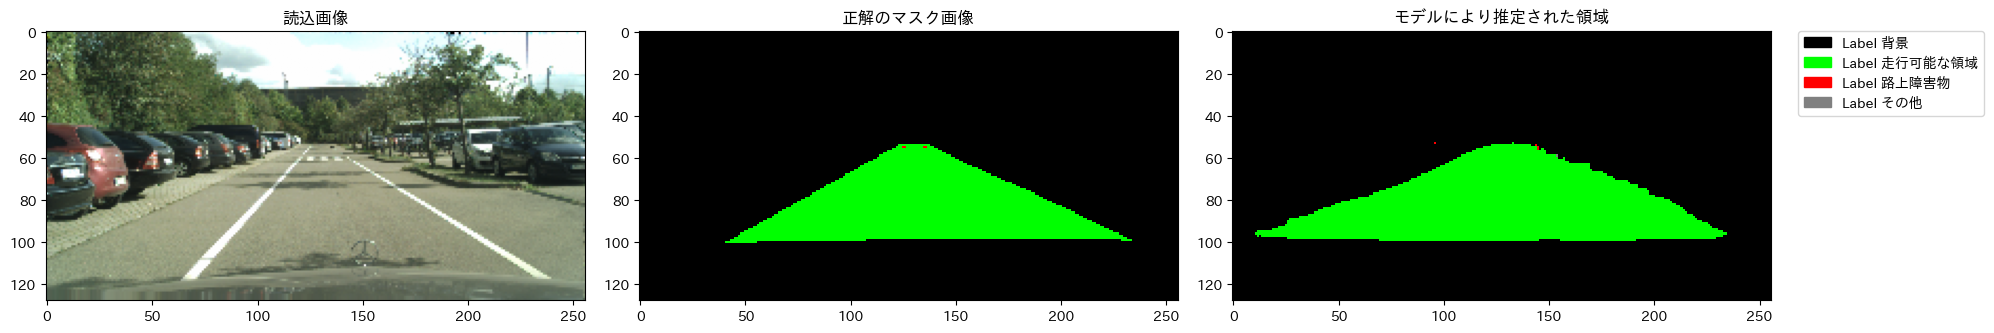


Sample Prediction after epoch 51

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.4313 - loss: 2.2105 - val_iou_score: 0.3237 - val_loss: 2.5887
Epoch 52/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - iou_score: 0.4367 - loss: 2.2135 - val_iou_score: 0.3240 - val_loss: 2.5875
Epoch 53/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - iou_score: 0.4458 - loss: 2.1284 - val_iou_score: 0.3354 - val_loss: 2.5474
Epoch 54/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - iou_score: 0.4462 - loss: 2.1239 - val_iou_score: 0.3392 - val_loss: 2.5361
Epoch 55/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 848ms/step - iou_score: 0.4423 - loss: 2.1763 - val_iou_score: 0.3394 - val_loss: 2.5391
Epoch 56/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 853ms/step - iou_score: 0.4564 - loss: 2.0828 - val_iou_score: 0.3365 - val_loss: 2.5314
Epoch 57/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 919ms/step - iou_score: 0.4537 - loss: 2.0998 - val_iou_score: 0.3469 - val_loss: 2.5025
Epoch 58/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.4680 - los

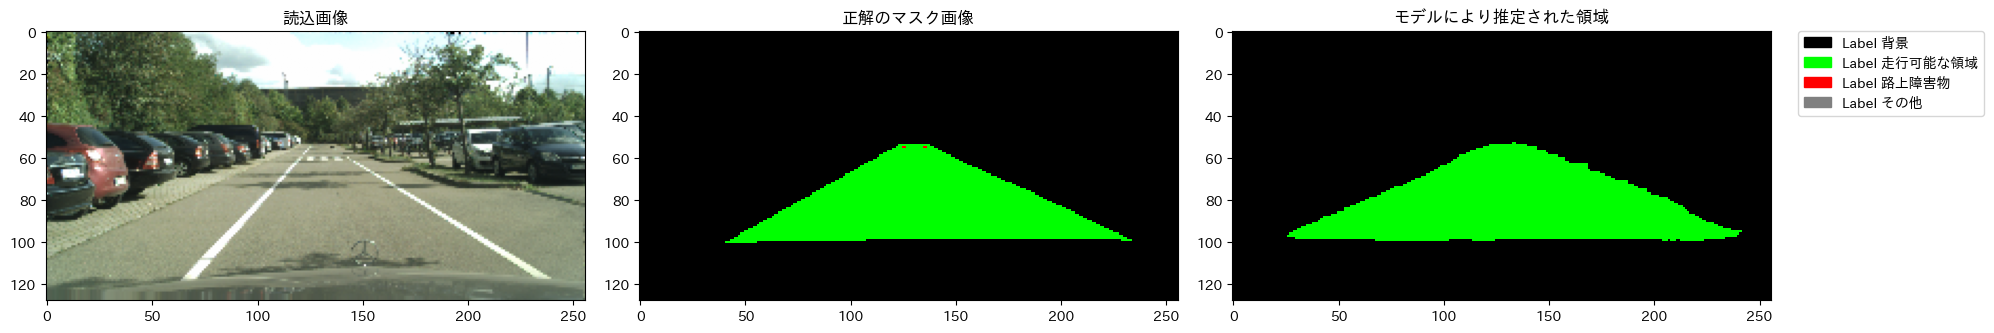


Sample Prediction after epoch 61

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.4676 - loss: 2.0969 - val_iou_score: 0.3659 - val_loss: 2.4387
Epoch 62/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - iou_score: 0.4771 - loss: 1.9818 - val_iou_score: 0.3665 - val_loss: 2.4362
Epoch 63/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - iou_score: 0.4868 - loss: 1.9739 - val_iou_score: 0.3716 - val_loss: 2.4157
Epoch 64/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 956ms/step - iou_score: 0.4904 - loss: 1.9231 - val_iou_score: 0.3731 - val_loss: 2.4203
Epoch 65/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.5025 - loss: 1.8626 - val_iou_score: 0.3764 - val_loss: 2.4127
Epoch 66/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 716ms/step - iou_score: 0.4794 - loss: 1.9806 - val_iou_score: 0.3813 - val_loss: 2.3947
Epoch 67/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 607ms/step - iou_score: 0.5191 - loss: 1.8507 - val_iou_score: 0.3776 - val_loss: 2.3985
Epoch 68/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 817ms/step - iou_score: 0.5153 -

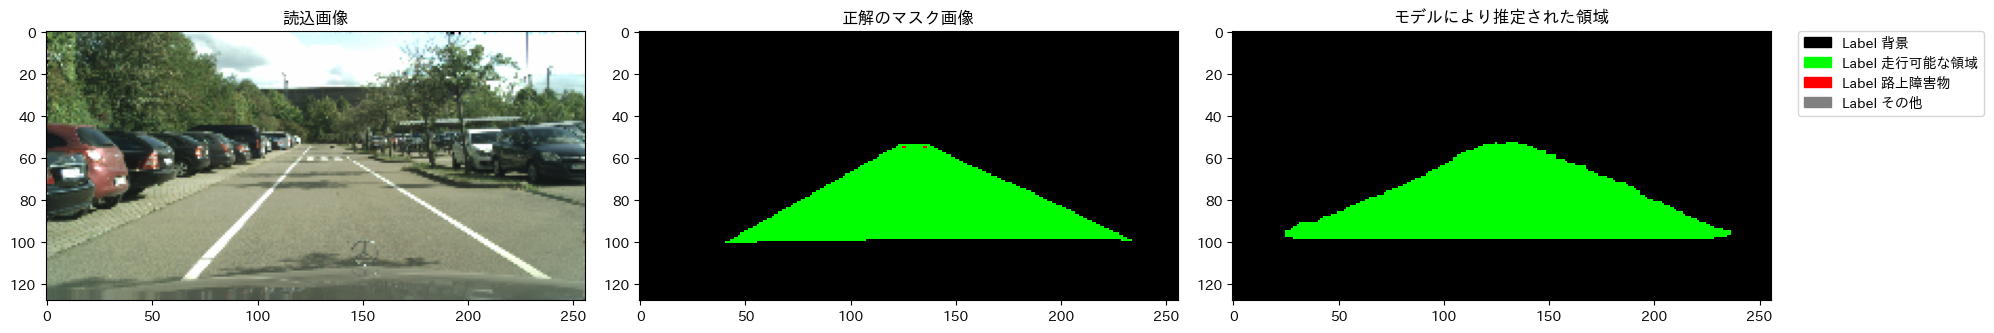


Sample Prediction after epoch 71

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.5386 - loss: 1.7061 - val_iou_score: 0.3919 - val_loss: 2.3545
Epoch 72/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 654ms/step - iou_score: 0.5205 - loss: 1.7856 - val_iou_score: 0.3810 - val_loss: 2.3877
Epoch 73/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 807ms/step - iou_score: 0.5574 - loss: 1.6588 - val_iou_score: 0.3888 - val_loss: 2.3637
Epoch 74/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 827ms/step - iou_score: 0.5419 - loss: 1.7068 - val_iou_score: 0.3898 - val_loss: 2.3738
Epoch 75/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.5536 - loss: 1.6448 - val_iou_score: 0.3853 - val_loss: 2.4007
Epoch 76/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 850ms/step - iou_score: 0.5527 - loss: 1.7019 - val_iou_score: 0.3874 - val_loss: 2.3921
Epoch 77/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 647ms/step - iou_score: 0.5671 - loss: 1.6001 - val_iou_score: 0.3914 - val_loss: 2.3836
Epoch 78/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.5694 - los

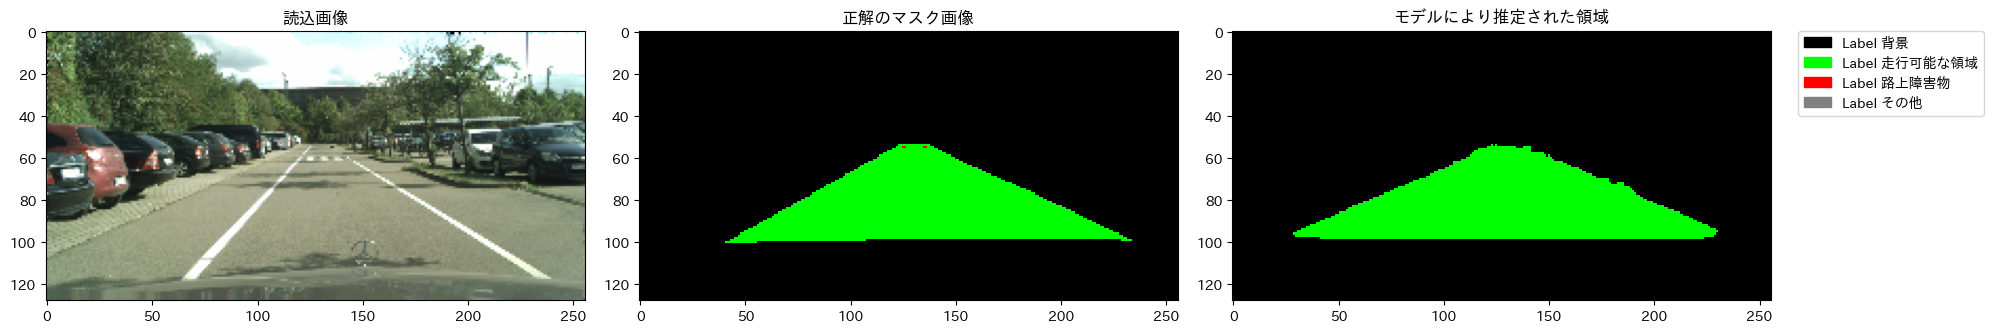


Sample Prediction after epoch 81

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.5940 - loss: 1.5623 - val_iou_score: 0.4056 - val_loss: 2.2983
Epoch 82/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 845ms/step - iou_score: 0.5605 - loss: 1.6508 - val_iou_score: 0.3888 - val_loss: 2.3687
Epoch 83/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - iou_score: 0.5732 - loss: 1.5885 - val_iou_score: 0.3931 - val_loss: 2.3292
Epoch 84/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 519ms/step - iou_score: 0.6128 - loss: 1.4465 - val_iou_score: 0.4054 - val_loss: 2.3084
Epoch 85/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 694ms/step - iou_score: 0.6046 - loss: 1.4835 - val_iou_score: 0.3962 - val_loss: 2.3286
Epoch 86/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.5791 - loss: 1.5465 - val_iou_score: 0.4014 - val_loss: 2.3204
Epoch 87/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 859ms/step - iou_score: 0.6093 - loss: 1.4770 - val_iou_score: 0.4161 - val_loss: 2.2461
Epoch 88/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 891ms/step - iou_score: 0.6010 -

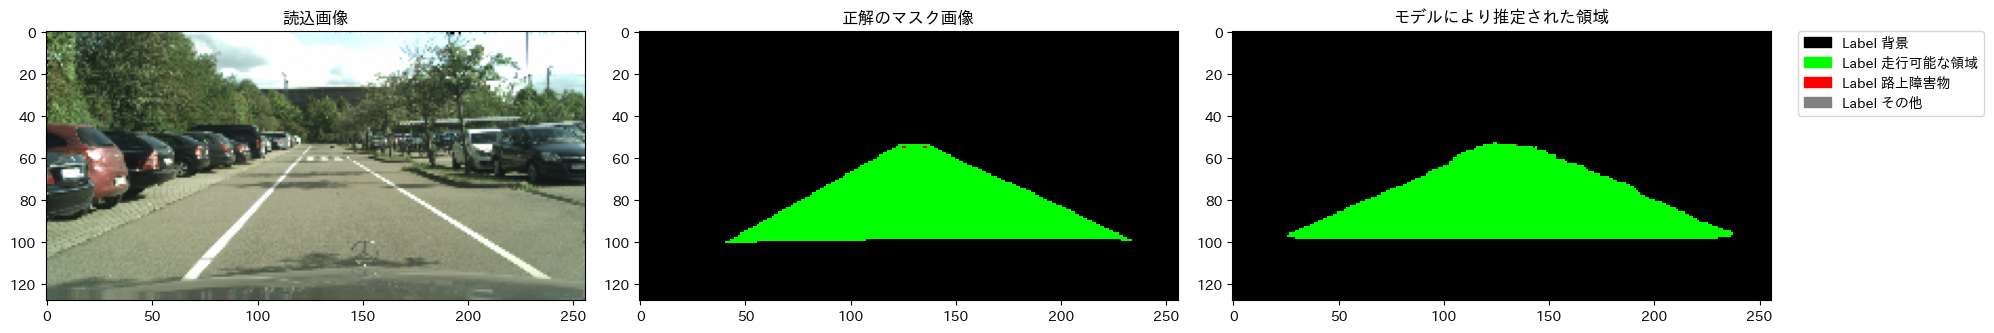


Sample Prediction after epoch 91

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.6423 - loss: 1.3633 - val_iou_score: 0.4015 - val_loss: 2.3065
Epoch 92/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - iou_score: 0.6339 - loss: 1.3909 - val_iou_score: 0.4234 - val_loss: 2.2173
Epoch 93/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 616ms/step - iou_score: 0.6105 - loss: 1.4435 - val_iou_score: 0.4142 - val_loss: 2.2545
Epoch 94/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 966ms/step - iou_score: 0.6144 - loss: 1.4151 - val_iou_score: 0.4209 - val_loss: 2.2319
Epoch 95/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 799ms/step - iou_score: 0.6405 - loss: 1.3874 - val_iou_score: 0.4040 - val_loss: 2.2860
Epoch 96/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6308 - loss: 1.4027 - val_iou_score: 0.4143 - val_loss: 2.2487
Epoch 97/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.6551 - loss: 1.3271 - val_iou_score: 0.4124 - val_loss: 2.2543
Epoch 98/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 637ms/step - iou_score: 0.6740 - los

In [11]:
# ※このコードセルは，実行完了までに15分かかります．

# 訓練中に推論画像を出力するためのコード
class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, validation_dataset):
        super().__init__()
        self.validation_data = validation_dataset

    def on_epoch_end(self, epoch, logs):
        # 10 Epoch毎に推論画像を出力する
        if (epoch % 10 == 0) :
            show_predictions(self.validation_data)
            print('\nSample Prediction after epoch {}\n'.format(epoch+1))

###
#  Focal Tversky Loss (マルチクラス拡張版)
#  マスク領域の広さが不均衡なデータに対し，比較的頑健な損失関数
###

## 100 Epoch (実行時間/14分)

def class_tversky(y_true: tf.Tensor, y_pred: tf.Tensor):
    smooth = 1

    true_pos = tf.reduce_sum(y_true * y_pred, axis=(0, 1, 2))
    false_neg = tf.reduce_sum(y_true * (1-y_pred), axis=(0, 1, 2))
    false_pos = tf.reduce_sum((1-y_true) * y_pred, axis=(0, 1, 2))
    alpha = 0.7
    return (true_pos + smooth) / (true_pos + alpha * false_neg + (1-alpha) * false_pos + smooth)

def focal_tversky_loss(y_true: tf.Tensor, y_pred: tf.Tensor):
    pt_1 = class_tversky(y_true, y_pred)
    gamma = 0.75
    return tf.reduce_sum( (1-pt_1)**gamma )


tf.keras.backend.set_image_data_format('channels_last')


model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    tf.keras.optimizers.Adam(1.0e-4),
    loss=focal_tversky_loss,
    metrics=[sm.metrics.iou_score],
)

# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))
callbacks.append(DisplayCallback(valid_dataset))

# モデルの訓練
model_history = model.fit(
   x = train_dataset,
   epochs = 100,
   validation_data = valid_dataset,
   steps_per_epoch = STEPS_PER_EPOCH,
   validation_steps = VALIDATION_STEPS,
   callbacks = callbacks
)

## モデルの評価

### 訓練済モデルによる推論

In [12]:
train_loss, train_iou = model.evaluate(train_dataset, steps = (TRAIN_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (train): {:.4}".format(train_loss))
print("iou (train): {:.4}".format(train_iou))

print()

test_loss, test_iou = model.evaluate(test_dataset, steps = (TEST_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (test): {:.4}".format(test_loss))
print("iou (test): {:.4}".format(test_iou))

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - iou_score: 0.4937 - loss: 1.9271
loss (train): 1.927
iou (train): 0.4937

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - iou_score: 0.4288 - loss: 2.2406
loss (test): 2.241
iou (test): 0.4288


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### 損失関数と評価指標の推移

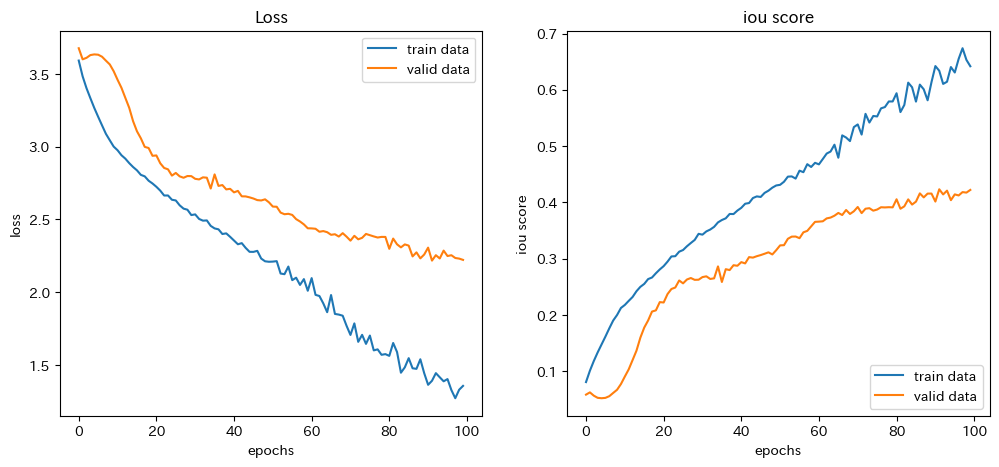

In [13]:
log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["iou_score"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_iou_score"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("iou score")
axes[1].legend(loc="lower right")
axes[1].set_title("iou score")

plt.show()

### 訓練済モデルによる推定例

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
[0 1 2]


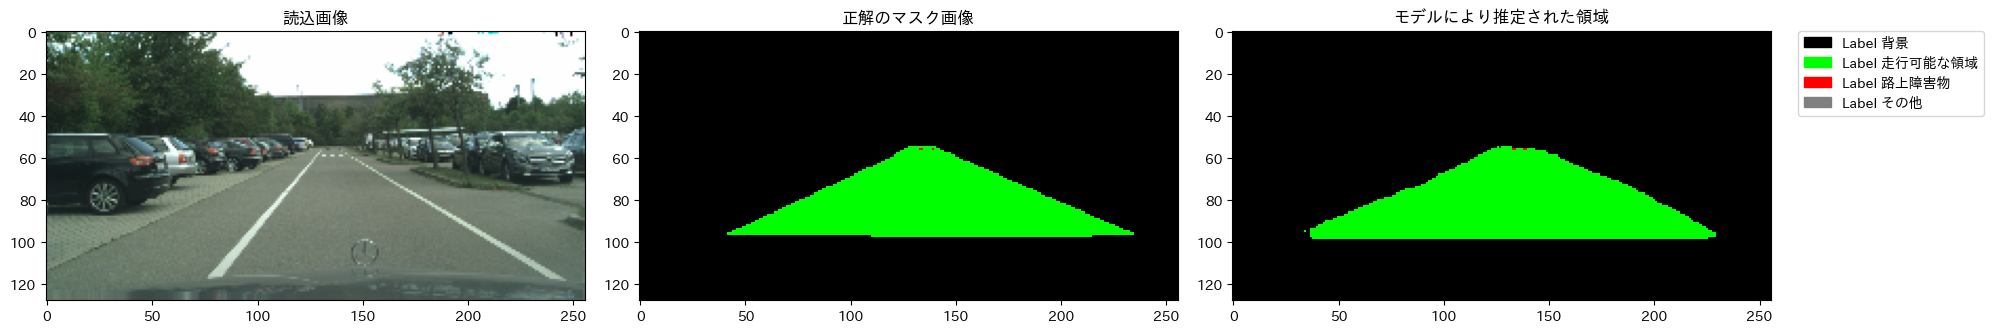

In [14]:
# 訓練用データセット
show_predictions(train_dataset, num=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[0 1 2]


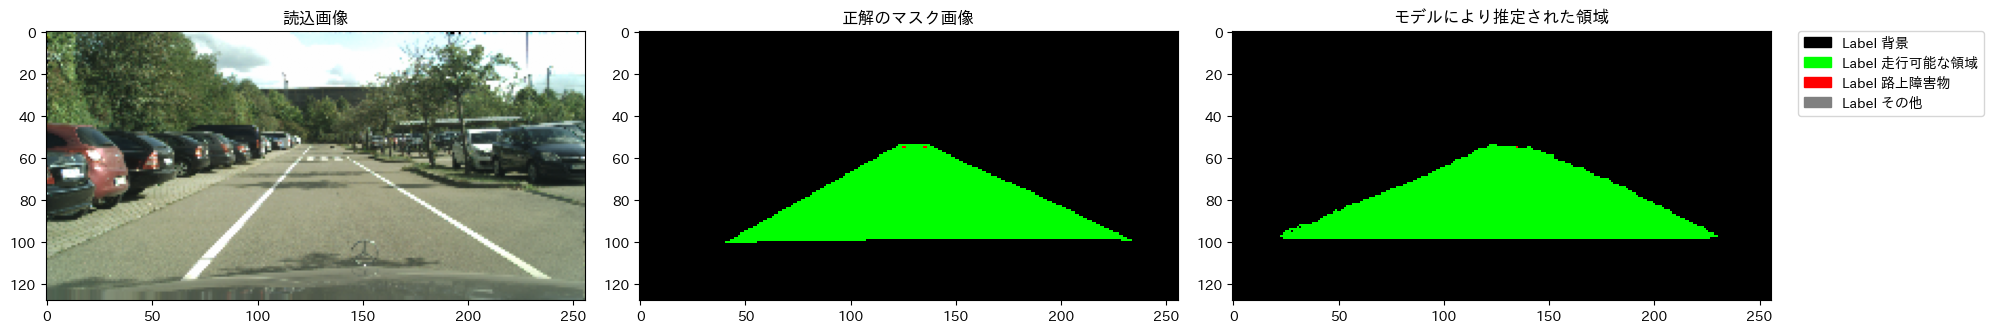

In [15]:
# 検証用データセット
show_predictions(valid_dataset, num=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[0 1 2]


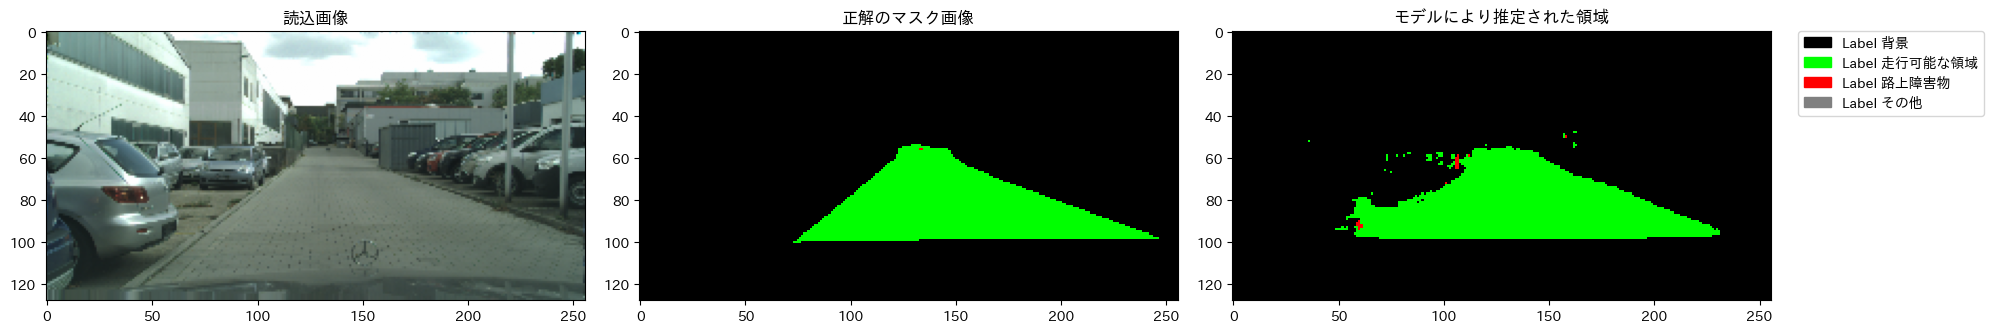

In [16]:
# テスト用データセット
show_predictions(test_dataset, num=1)